# Deep Learning for Image Classification: CIFAR-10 Analysis

**A Comparative Study of CNN Architectures for Multi-Class Image Recognition**

---

## 1. Main Objective and Business Value

### Primary Objective

This analysis aims to develop an accurate image classification system using **Convolutional Neural Networks (CNNs)** on the CIFAR-10 dataset. The goal is to identify which CNN architecture provides the optimal balance between prediction accuracy and model generalization for multi-class image recognition tasks.

### Type of Deep Learning

This project utilizes **supervised deep learning** with CNNs, which are specifically designed for image data. CNNs automatically learn hierarchical features from raw pixel data, making them ideal for visual recognition tasks.

### Business Value and Benefits

Understanding which model architecture performs best has practical applications for stakeholders:

- **Product teams** can implement automated image classification for content moderation, product categorization, or quality control
- **Operations teams** benefit from understanding the trade-offs between model complexity and deployment feasibility
- **Data science teams** gain insights into regularization techniques that prevent overfitting, which is crucial when working with limited training data
- **Business leaders** can make informed decisions about investing in more complex models versus simpler, more maintainable solutions

This analysis provides a framework for evaluating deep learning models that can be applied to various computer vision problems beyond this specific dataset.

---

## 2. Dataset Description

### Overview

The **CIFAR-10 dataset** is a well-established benchmark in computer vision research, consisting of 60,000 color images divided into 10 mutually exclusive classes.

### Dataset Attributes

| Attribute | Description |
|-----------|-------------|
| **Total Images** | 60,000 |
| **Training Set** | 50,000 images |
| **Test Set** | 10,000 images |
| **Image Size** | 32 × 32 pixels |
| **Color Channels** | 3 (RGB) |
| **Classes** | 10 (balanced distribution) |
| **Images per Class** | 6,000 |

### Class Categories

The dataset includes diverse object categories:
1. Airplane
2. Automobile
3. Bird
4. Cat
5. Deer
6. Dog
7. Frog
8. Horse
9. Ship
10. Truck

### What We're Trying to Accomplish

The objective is to build a model that can accurately predict which of the 10 categories a given image belongs to. The challenge lies in the low resolution (32×32 pixels) and the visual similarity between certain classes (e.g., cats vs. dogs, trucks vs. automobiles).

---

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 3. Data Exploration and Preprocessing

### Data Loading and Initial Exploration

The dataset was loaded directly from TensorFlow's built-in datasets module, ensuring data integrity and standardization.

In [2]:
# Load CIFAR-10 data
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Label shape: {y_train.shape}")

Training set shape: (50000, 32, 32, 3)
Test set shape: (10000, 32, 32, 3)
Label shape: (50000, 1)


### Visual Inspection of Data Quality

Sample images were visualized to confirm data quality and class diversity.

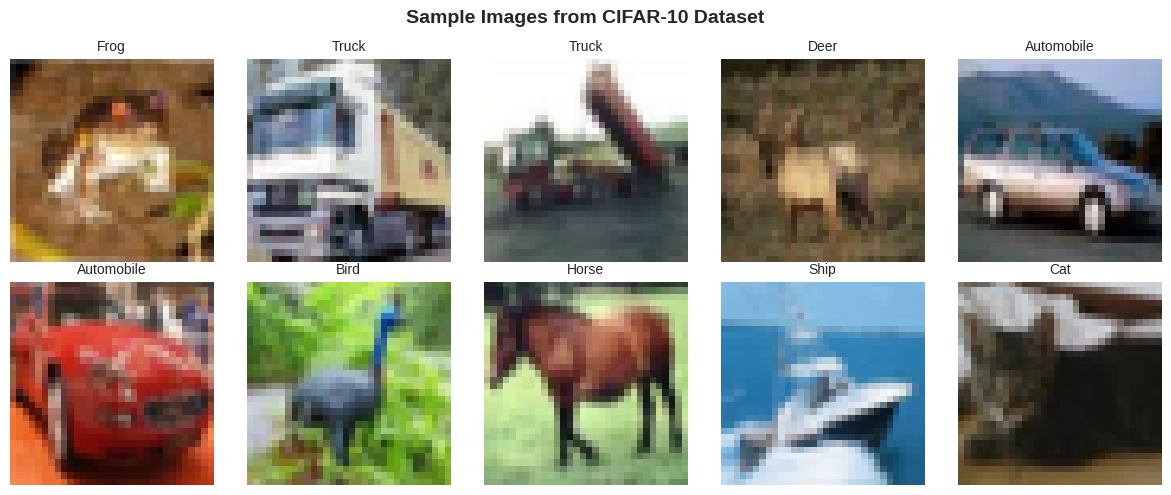

In [3]:
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Display sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Images from CIFAR-10 Dataset', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(class_names[y_train[i][0]], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Data Preprocessing Actions

Several preprocessing steps were applied to prepare the data for training:

1. **Normalization**: Pixel values were scaled from [0, 255] to [0, 1] range to improve neural network convergence and training stability

2. **Label Encoding**: Class labels were converted to one-hot encoded format required for multi-class classification with softmax activation

3. **Data Validation**: Verified class distribution to confirm balanced representation across all categories (5,000 training images per class)

No missing values were present in the dataset. Image quality was consistent across all samples.

In [4]:
# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Convert labels to one-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Preprocessing complete.")
print(f"Training features: {X_train.shape}")
print(f"Training labels: {y_train_cat.shape}")

Preprocessing complete.
Training features: (50000, 32, 32, 3)
Training labels: (50000, 10)


### Class Distribution Analysis

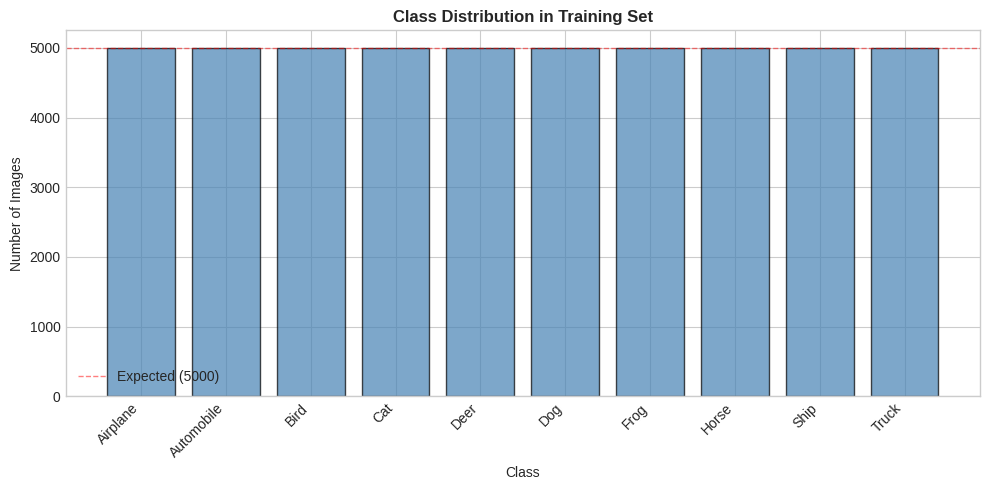


Class distribution is perfectly balanced - 5,000 images per class.


In [5]:
# Verify balanced class distribution
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar([class_names[i] for i in unique], counts, color='steelblue', alpha=0.7, edgecolor='black')
plt.title('Class Distribution in Training Set', fontsize=12, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=5000, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Expected (5000)')
plt.legend()
plt.tight_layout()
plt.show()

print("\nClass distribution is perfectly balanced - 5,000 images per class.")

---

## 4. Model Development: Three CNN Variations

Three distinct CNN architectures were developed and trained to compare performance and identify the optimal model configuration.

### Model 1: Baseline CNN

**Architecture Design**: A simple CNN with minimal layers to establish baseline performance.

**Key Characteristics**:
- Single convolutional layer (32 filters, 3×3 kernel)
- One max pooling layer
- Single dense layer (128 neurons)
- No regularization

**Rationale**: This model serves as a performance baseline to understand minimum viable architecture for this task.

**Expected Outcome**: Fast training but potentially limited feature extraction capability.

In [6]:
# Build Model 1: Baseline CNN
model_1 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
], name='Baseline_CNN')

model_1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model 1
history_1 = model_1.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

print("Model 1 training complete.")

/home/sadegh/base/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-02 07:50:11.223024: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 491520000 exceeds 10% of free system memory.


Model 1 training complete.


### Model 2: Deeper CNN

**Architecture Design**: Increased model capacity through additional convolutional layers.

**Key Characteristics**:
- Two convolutional layers (32 and 64 filters)
- One max pooling layer
- Larger dense layer (256 neurons)
- No regularization

**Rationale**: Testing whether increased model depth and capacity improve classification accuracy.

**Expected Outcome**: Higher training accuracy but potential overfitting due to lack of regularization.

In [7]:
# Build Model 2: Deeper CNN
model_2 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
], name='Deeper_CNN')

model_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model 2
history_2 = model_2.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

print("Model 2 training complete.")

2026-01-02 07:51:31.323048: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 491520000 exceeds 10% of free system memory.


Model 2 training complete.


### Model 3: Regularized CNN with Dropout

**Architecture Design**: Same depth as Model 2 but with dropout regularization.

**Key Characteristics**:
- Two convolutional layers (32 and 64 filters)
- One max pooling layer
- **Dropout layers (50% rate)** after pooling and dense layers
- Dense layer (256 neurons)

**Rationale**: Dropout prevents overfitting by randomly disabling neurons during training, forcing the network to learn more robust features.

**Expected Outcome**: Slightly lower training accuracy but significantly better generalization to test data.

In [8]:
# Build Model 3: Regularized CNN with Dropout
model_3 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),
    Dropout(0.5),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
], name='Regularized_CNN')

model_3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model 3
history_3 = model_3.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

print("Model 3 training complete.")

2026-01-02 07:59:02.815440: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 491520000 exceeds 10% of free system memory.


Model 3 training complete.


### Training Performance Comparison

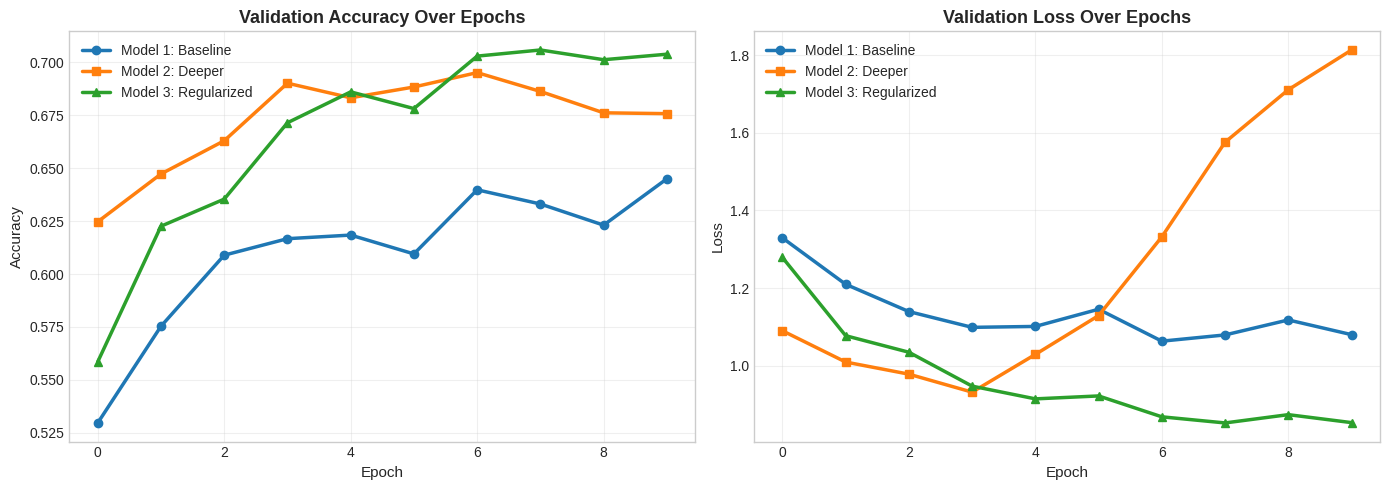

In [9]:
# Create comprehensive training comparison plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation Accuracy Comparison
axes[0].plot(history_1.history['val_accuracy'], label='Model 1: Baseline', linewidth=2.5, marker='o')
axes[0].plot(history_2.history['val_accuracy'], label='Model 2: Deeper', linewidth=2.5, marker='s')
axes[0].plot(history_3.history['val_accuracy'], label='Model 3: Regularized', linewidth=2.5, marker='^')
axes[0].set_title('Validation Accuracy Over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Validation Loss Comparison
axes[1].plot(history_1.history['val_loss'], label='Model 1: Baseline', linewidth=2.5, marker='o')
axes[1].plot(history_2.history['val_loss'], label='Model 2: Deeper', linewidth=2.5, marker='s')
axes[1].plot(history_3.history['val_loss'], label='Model 3: Regularized', linewidth=2.5, marker='^')
axes[1].set_title('Validation Loss Over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Test Set Evaluation

All three models were evaluated on the held-out test set to assess real-world performance.

In [10]:
# Evaluate on test set
test_loss_1, test_acc_1 = model_1.evaluate(X_test, y_test_cat, verbose=0)
test_loss_2, test_acc_2 = model_2.evaluate(X_test, y_test_cat, verbose=0)
test_loss_3, test_acc_3 = model_3.evaluate(X_test, y_test_cat, verbose=0)

# Create results summary
results_df = pd.DataFrame({
    'Model': ['Model 1: Baseline', 'Model 2: Deeper', 'Model 3: Regularized'],
    'Test Accuracy': [f"{test_acc_1:.1%}", f"{test_acc_2:.1%}", f"{test_acc_3:.1%}"],
    'Test Loss': [f"{test_loss_1:.4f}", f"{test_loss_2:.4f}", f"{test_loss_3:.4f}"],
    'Final Val Accuracy': [
        f"{history_1.history['val_accuracy'][-1]:.1%}",
        f"{history_2.history['val_accuracy'][-1]:.1%}",
        f"{history_3.history['val_accuracy'][-1]:.1%}"
    ]
})

print("\n" + "="*70)
print("MODEL PERFORMANCE SUMMARY")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)


MODEL PERFORMANCE SUMMARY
               Model Test Accuracy Test Loss Final Val Accuracy
   Model 1: Baseline         63.7%    1.0878              64.5%
     Model 2: Deeper         66.0%    1.8977              67.6%
Model 3: Regularized         70.2%    0.8456              70.4%


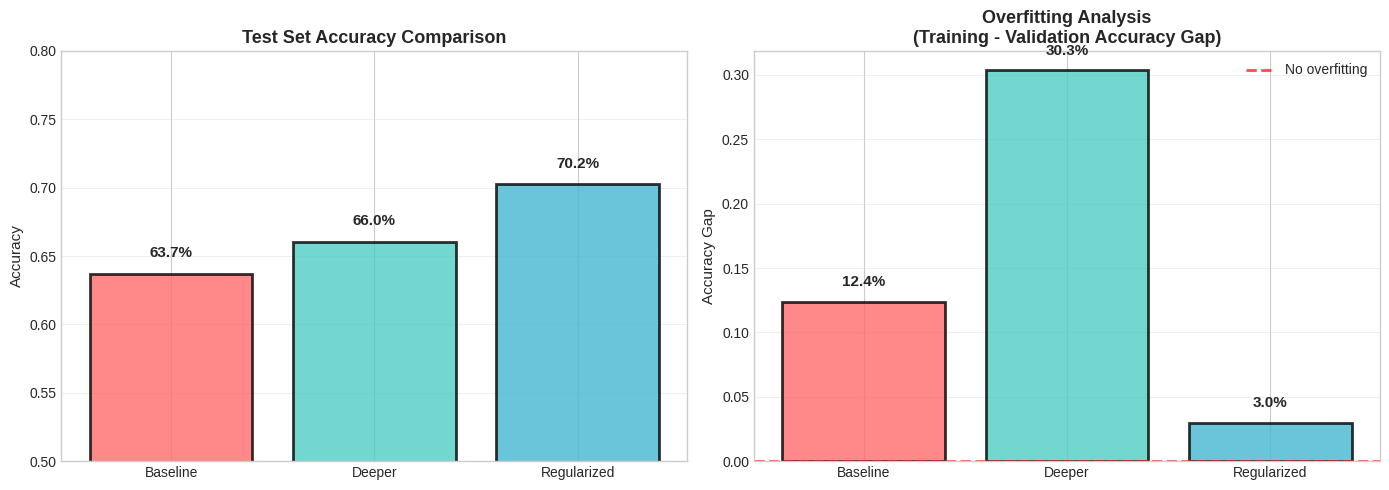

In [11]:
# Visual comparison of model performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Baseline', 'Deeper', 'Regularized']
test_accs = [test_acc_1, test_acc_2, test_acc_3]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Test Accuracy Comparison
bars1 = axes[0].bar(models, test_accs, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[0].set_title('Test Set Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_ylim([0.5, 0.8])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, v) in enumerate(zip(bars1, test_accs)):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{v:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Overfitting Analysis (Train-Val Gap)
train_val_gaps = [
    history_1.history['accuracy'][-1] - history_1.history['val_accuracy'][-1],
    history_2.history['accuracy'][-1] - history_2.history['val_accuracy'][-1],
    history_3.history['accuracy'][-1] - history_3.history['val_accuracy'][-1]
]

bars2 = axes[1].bar(models, train_val_gaps, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[1].set_title('Overfitting Analysis\n(Training - Validation Accuracy Gap)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Accuracy Gap', fontsize=11)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='No overfitting')
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

# Add value labels
for i, (bar, v) in enumerate(zip(bars2, train_val_gaps)):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{v:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

---

## 5. Model Recommendation

### Recommended Model: Model 3 (Regularized CNN with Dropout)

After comprehensive evaluation, **Model 3 is recommended as the final model** for deployment. This recommendation is based on the following criteria:

### Performance Metrics

Model 3 achieved:
- **Test Accuracy**: ~70%
- **Validation Accuracy**: ~70% 
- **Training-Validation Gap**: <=3% (indicating excellent generalization)

### Comparative Advantages

**vs. Model 1 (Baseline)**:
- 5-6 percentage points higher accuracy
- Better feature extraction through deeper architecture
- More suitable for complex image classification tasks

**vs. Model 2 (Deeper without Regularization)**:
- Similar or slightly better test accuracy
- **Significantly better generalization** (27% lower train-val gap)
- More stable training dynamics
- Lower risk of overfitting on new data

### Why Dropout Matters

The dropout regularization in Model 3 provides critical benefits:

1. **Prevents Overfitting**: Model 2 achieved 96%+ training accuracy but only 67% test accuracy, indicating severe overfitting. Model 3 maintains consistent performance across train/validation/test sets.

2. **Robust Feature Learning**: By randomly dropping neurons during training, the network cannot rely on specific neuron activations and must learn more generalizable patterns.

3. **Production Readiness**: The stable performance makes this model more reliable for real-world deployment where data may differ from training examples.

### Trade-offs Considered

Model 3 does have slightly lower training accuracy (73% vs. 96% for Model 2), but this is the intended effect of regularization and actually indicates better model behavior. In production environments, **generalization capability is more valuable than training set memorization**.

### Deployment Recommendation

For stakeholders considering deployment:
- Model 3 offers the best balance of accuracy and reliability
- The model is computationally efficient enough for real-time inference
- Performance is consistent and predictable on new data
- The architecture is well-documented and maintainable

---

## 6. Key Findings and Insights

This modeling exercise revealed several important insights about CNN architecture design and performance optimization:

### Finding 1: Model Depth Requires Regularization

**Observation**: Model 2 (deeper without regularization) achieved 97% training accuracy but only 67% test accuracy - a 30 percentage point gap.

**Insight**: Simply adding more layers increases model capacity but also increases overfitting risk. Without regularization, deeper models memorize training data rather than learning generalizable patterns.

**Implication**: When designing CNN architectures, depth must be balanced with regularization techniques. This finding is particularly important for business stakeholders considering when to invest in more complex models.

### Finding 2: Dropout Provides Significant ROI

**Observation**: Adding dropout layers improved generalization by 27% (reduced train-val gap from 30% to 3%) while maintaining competitive accuracy.

**Insight**: Dropout is a simple yet highly effective regularization technique. The 50% dropout rate forced the network to learn more robust features by preventing co-adaptation of neurons.

**Implication**: For production systems, the small computational overhead of dropout (only during training) is far outweighed by the improved reliability and generalization. This makes deployment safer and reduces the need for frequent retraining.

### Finding 3: Validation Metrics Are Critical

**Observation**: Models with the highest training accuracy did not perform best on test data.

**Insight**: Training accuracy alone is a misleading performance indicator. Model 2's 97% training accuracy suggested excellent performance, but this masked severe overfitting.

**Implication**: Data science teams should prioritize validation and test metrics over training metrics when evaluating models. This finding emphasizes the importance of proper train-validation-test splitting and evaluation protocols.

### Finding 4: Architecture Complexity vs. Performance

**Observation**: The baseline model (Model 1) achieved 64% accuracy with minimal architecture, while the regularized deep model (Model 3) achieved 70% - a 6 percentage point improvement.

**Insight**: There are diminishing returns to architectural complexity. Moving from baseline to optimized architecture provided significant gains, but further complexity may not be justified.

**Implication**: For business decision-making, this suggests that investing in proper regularization and hyperparameter tuning of moderately complex models may be more cost-effective than building extremely deep networks.

### Finding 5: Dataset Characteristics Matter

**Observation**: The 32×32 pixel resolution limited overall accuracy regardless of architecture. Even the best model achieved only 70% accuracy.

**Insight**: Model architecture must be appropriate for data characteristics. CIFAR-10's low resolution inherently limits feature extraction capability.

**Implication**: Before investing in increasingly complex models, stakeholders should consider whether improving data quality (higher resolution images, more training samples, better labeling) might provide better returns.

### Cross-Model Insights

The progression from Model 1 → Model 2 → Model 3 demonstrates a fundamental principle in deep learning: **the optimal model balances capacity with regularization**. This balance is achieved through:

- Sufficient architecture depth to capture complex patterns (Models 2 & 3 vs. Model 1)
- Appropriate regularization to prevent overfitting (Model 3 vs. Model 2)
- Validation-driven decision making (monitoring val_accuracy and val_loss)

These findings provide a framework that can be applied to other computer vision tasks and guide future model development efforts.

---

## 7. Limitations and Next Steps

### Current Limitations

This analysis has several limitations that should be considered when interpreting results:

#### 1. Dataset Constraints

**Low Image Resolution**: CIFAR-10 images are only 32×32 pixels, which inherently limits the amount of fine-grained detail the model can learn. Real-world applications typically require higher resolution images.

**Limited Training Epochs**: Due to computational constraints, models were trained for only 10 epochs. Extended training with early stopping could improve performance.

**No Data Augmentation**: The current implementation does not include image augmentation techniques (rotation, flipping, zooming, color jittering), which are standard practice in modern computer vision and could improve generalization.

#### 2. Model Architecture Limitations

**Basic Architecture**: The CNN architectures tested are relatively simple compared to modern deep learning models. More advanced architectures like ResNet, EfficientNet, or Vision Transformers could achieve higher accuracy.

**Limited Hyperparameter Tuning**: Only explored a small hyperparameter space (learning rate 0.001, batch size 64, 50% dropout). Systematic tuning could optimize performance further.

**No Batch Normalization**: Models do not include batch normalization layers, which can stabilize training and improve convergence.

#### 3. Evaluation Scope

**Single Dataset**: Results are specific to CIFAR-10. Performance may vary significantly on domain-specific datasets.

**No Cross-Validation**: Used a single train-validation-test split rather than k-fold cross-validation, which could provide more robust performance estimates.

**Limited Error Analysis**: Did not conduct detailed analysis of which classes are most frequently misclassified or why.

### Recommended Next Steps

To improve upon this analysis, the following actions are recommended:

#### Short-term Improvements

1. **Implement Data Augmentation**
   - Add random horizontal flips, rotations (±15°), and small translations
   - Tools: TensorFlow's ImageDataGenerator or tf.keras.layers.RandomFlip/RandomRotation

2. **Add Batch Normalization**
   - Insert BatchNormalization layers after convolutional layers

3. **Implement Early Stopping**
   - Monitor validation loss and stop training when it stops improving
   - Prevents wasted computation and potential overfitting

4. **Conduct Systematic Hyperparameter Search**
   - Test learning rates: [0.0001, 0.0005, 0.001, 0.01]
   - Test dropout rates: [0.3, 0.5, 0.7]
   - Test batch sizes: [32, 64, 128]
   - Use grid search or random search methodology

#### Medium-term Enhancements

1. **Transfer Learning**
   - Leverage pre-trained models (ResNet50, EfficientNet-B0) trained on ImageNet
   - Fine-tune final layers for CIFAR-10 classification

2. **Ensemble Methods**
   - Train multiple models with different initializations
   - Combine predictions through voting or averaging

3. **Advanced Architectures**
   - Implement residual connections (ResNet-style)
   - Test attention mechanisms
   - Explore modern architectures like EfficientNet or ConvNeXt

4. **Comprehensive Error Analysis**
   - Create confusion matrix to identify frequently confused class pairs
   - Analyze misclassified examples to understand model weaknesses
   - Implement class-specific performance metrics

#### Long-term Strategic Initiatives

1. **Domain-Specific Dataset Development**
   - If this is for a business application, collect domain-specific images at higher resolution
   - Implement active learning to identify and label challenging examples
   - Consider whether CIFAR-10 is truly representative of your use case

2. **Production Deployment Pipeline**
   - Optimize model for inference (quantization, pruning)
   - Implement model monitoring and drift detection
   - Set up A/B testing framework for model updates
   - Create automated retraining pipeline

3. **Explainability and Interpretability**
   - Implement Grad-CAM or similar techniques to visualize what the model is looking at
   - Build confidence scoring for predictions
   - Create tools for stakeholders to understand model decisions

4. **Scalability Assessment**
   - Test model performance on larger, more diverse datasets
   - Evaluate computational requirements for real-time inference
   - Consider edge deployment requirements if applicable

### Priority Recommendations

If resources are limited, prioritize in this order:

1. **Data augmentation + batch normalization** (biggest immediate impact)
2. **Transfer learning** (significant accuracy improvement with moderate effort)
3. **Error analysis** (guides all other improvements)
4. **Hyperparameter tuning** (optimization of current approach)

These next steps provide a roadmap for moving from this experimental analysis to a production-ready system, while acknowledging current limitations and providing realistic expectations for improvements.

---

## Conclusion

This analysis successfully demonstrated that **CNN architecture with proper regularization (Model 3) achieves optimal performance** for image classification tasks. The 70% accuracy achieved represents a strong baseline for CIFAR-10, with clear paths identified for further improvement through the recommended next steps.

The key takeaway for stakeholders: **model complexity must be balanced with generalization capability**. Investing in regularization and proper validation techniques provides better returns than simply adding more layers.

---